In [ ]:
import pandas as pd
import requests
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Загрузка ресурсов NLTK (если ещё не загружены)
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

# Загрузка текста с GitHub
url = "https://raw.githubusercontent.com/Altaieb-Mohammed/lab_2corse/master/texts.txt"
response = requests.get(url)
response.raise_for_status()
text_data = response.text

# Разбиваем на строки и удаляем пустые
reviews = [line.strip() for line in text_data.split('\n') if line.strip()]

# Функции очистки и лемматизации
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = text.lower()
    text = re.sub(r'<.*?>', ' ', text)
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def preprocess_text(text):
    text = clean_text(text)
    words = text.split()
    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]
    return ' '.join(words)

cleaned_reviews = [preprocess_text(r) for r in reviews]

df = pd.DataFrame({'review': reviews, 'clean_review': cleaned_reviews})
print(df.head())


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


                                              review  \
0  a stirring , funny and finally transporting re...   
1  apparently reassembled from the cutting-room f...   
2  they presume their audience wo n't sit still f...   
3  this is a visually stunning rumination on love...   
4  jonathan parker 's bartleby should have been t...   

                                        clean_review  
0  stirring funny finally transporting reimaginin...  
1  apparently reassembled cuttingroom floor given...  
2  presume audience wo nt sit still sociology les...  
3  visually stunning rumination love memory histo...  
4  jonathan parker bartleby beallendall modernoff...  


In [ ]:
negative_keywords = [
    'bad', 'wretched', 'repugnant', 'lame', 'tedium', 'boring', 'disbelief',
    'failure', 'bloated', 'insufficiently', 'regrettably', 'lacks', 'worst',
    'worse', 'awful', 'terrible', 'dull', 'disappointing'
]

def auto_label(text):
    text_lower = text.lower()
    return 0 if any(word in text_lower for word in negative_keywords) else 1

df['sentiment'] = df['review'].apply(auto_label)
print(df['sentiment'].value_counts())


sentiment
1    9035
0     578
Name: count, dtype: int64


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(df['clean_review'])
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)

model = LinearSVC()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")


              precision    recall  f1-score   support

           0       0.98      0.75      0.85       173
           1       0.98      1.00      0.99      2711

    accuracy                           0.98      2884
   macro avg       0.98      0.88      0.92      2884
weighted avg       0.98      0.98      0.98      2884

Accuracy: 0.9844


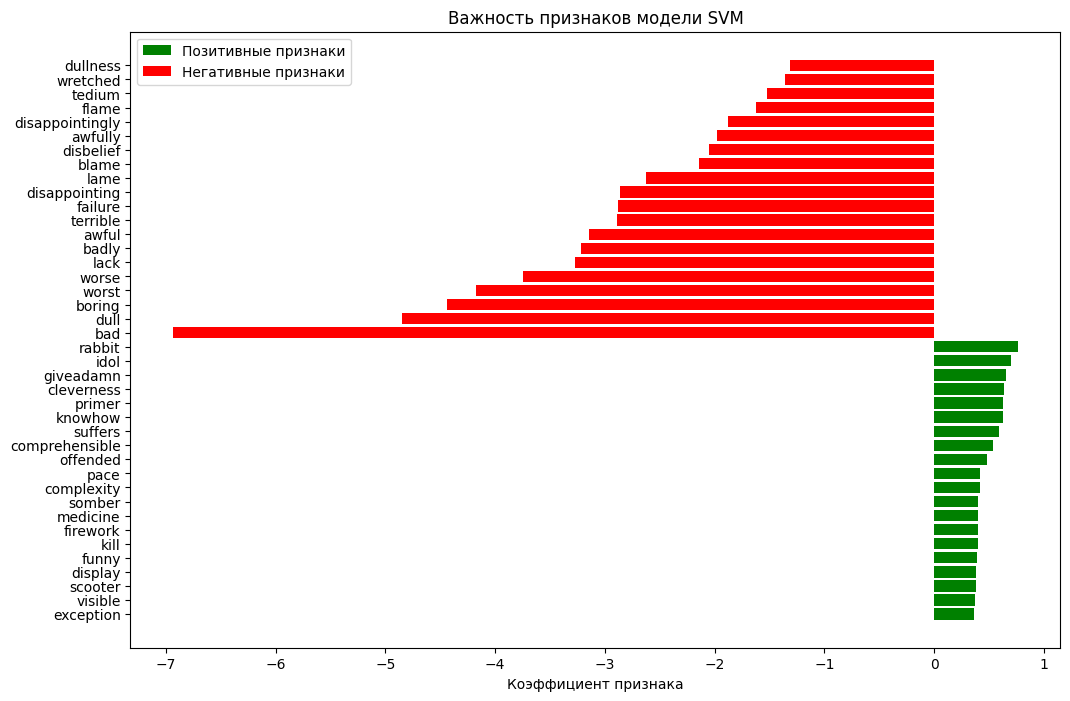

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

feature_names = vectorizer.get_feature_names_out()
coef = model.coef_.flatten()

top_pos = np.argsort(coef)[-20:]
top_neg = np.argsort(coef)[:20]

plt.figure(figsize=(12,8))
plt.barh(range(20), coef[top_pos], color='green', label='Позитивные признаки')
plt.barh(range(20,40), coef[top_neg], color='red', label='Негативные признаки')
plt.yticks(
    list(range(20)) + list(range(20,40)),
    list(feature_names[top_pos]) + list(feature_names[top_neg])
)
plt.xlabel('Коэффициент признака')
plt.title('Важность признаков модели SVM')
plt.legend()
plt.show()


In [1]:
# Пример новых отзывов для проверки
new_reviews = [
    "This movie was absolutely fantastic, I loved it!",
    "Terrible plot and bad acting, waste of time.",
    "An average film, nothing special but not bad either.",
    "I really enjoyed the soundtrack and visuals.",
    "The story was boring and predictable."
]

# Предобработка новых отзывов (используем ту же функцию preprocess_text)
new_reviews_clean = [preprocess_text(review) for review in new_reviews]

# Векторизация новых отзывов
X_new = vectorizer.transform(new_reviews_clean)

# Предсказание с помощью обученной модели SVM
predictions = model.predict(X_new)

for review, pred in zip(new_reviews, predictions):
    label = "Позитивный" if pred == 1 else "Негативный"
    print(f"Отзыв: {review}\nПредсказание: {label}\n")


NameError: name 'preprocess_text' is not defined